### Final Feature Engineering, Main Data Visualization and Data Analysis, Prepare data for model training

In [81]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import json

from utils_notebook import plot_num_count, plot_category_count

In [82]:
df = pd.read_csv("../data/highrise.csv")
df.head()

,property_type,mukim,scheme_name_area,tenure,land_parcel_area,unit_level,transaction_price,year
0,Condominium/Apartment,Kuala Lumpur Town Centre,1A STONOR APT (CONLAY COURT),Leasehold,613.542893,0,469000,2023
1,Condominium/Apartment,Kuala Lumpur Town Centre,1A STONOR APT (CONLAY COURT),Freehold,2120.490349,1,1260000,2024
2,Condominium/Apartment,Kuala Lumpur Town Centre,1A STONOR APT (CONLAY COURT),Leasehold,1119.446682,10,650000,2024
3,Condominium/Apartment,Kuala Lumpur Town Centre,1A STONOR APT (CONLAY COURT),Leasehold,1119.446682,6,580000,2025
4,Condominium/Apartment,Kuala Lumpur Town Centre,2 HAMPSHIRE,Freehold,3336.812224,23,2000000,2022


In [83]:
income = pd.read_csv("../data/mukim_income.csv")
income.rename(columns={"income_median_weighted":"income_median_area"}, inplace=True)
income.head()

,year,mukim,income_median_area
0,2021,Kuala Lumpur Town Centre,10310.350007
1,2021,Mukim Ampang,10128.651211
2,2021,Mukim Batu,10852.144960
3,2021,Mukim Cheras,9324.875947
4,2021,Mukim Kuala Lumpur,11221.583852


In [84]:
df = df.merge(income, on=['year', 'mukim'], how='left')
df.head()

,property_type,mukim,scheme_name_area,tenure,land_parcel_area,unit_level,transaction_price,year,income_median_area
0,Condominium/Apartment,Kuala Lumpur Town Centre,1A STONOR APT (CONLAY COURT),Leasehold,613.542893,0,469000,2023,10479.465763
1,Condominium/Apartment,Kuala Lumpur Town Centre,1A STONOR APT (CONLAY COURT),Freehold,2120.490349,1,1260000,2024,10655.952127
2,Condominium/Apartment,Kuala Lumpur Town Centre,1A STONOR APT (CONLAY COURT),Leasehold,1119.446682,10,650000,2024,10655.952127
3,Condominium/Apartment,Kuala Lumpur Town Centre,1A STONOR APT (CONLAY COURT),Leasehold,1119.446682,6,580000,2025,10655.952127
4,Condominium/Apartment,Kuala Lumpur Town Centre,2 HAMPSHIRE,Freehold,3336.812224,23,2000000,2022,10302.979398


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19818 entries, 0 to 19817
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_type       19818 non-null  object 
 1   mukim               19818 non-null  object 
 2   scheme_name_area    19818 non-null  object 
 3   tenure              19818 non-null  object 
 4   land_parcel_area    19818 non-null  float64
 5   unit_level          19818 non-null  int64  
 6   transaction_price   19818 non-null  int64  
 7   year                19818 non-null  int64  
 8   income_median_area  19818 non-null  float64
dtypes: float64(2), int64(3), object(4)
memory usage: 1.4+ MB


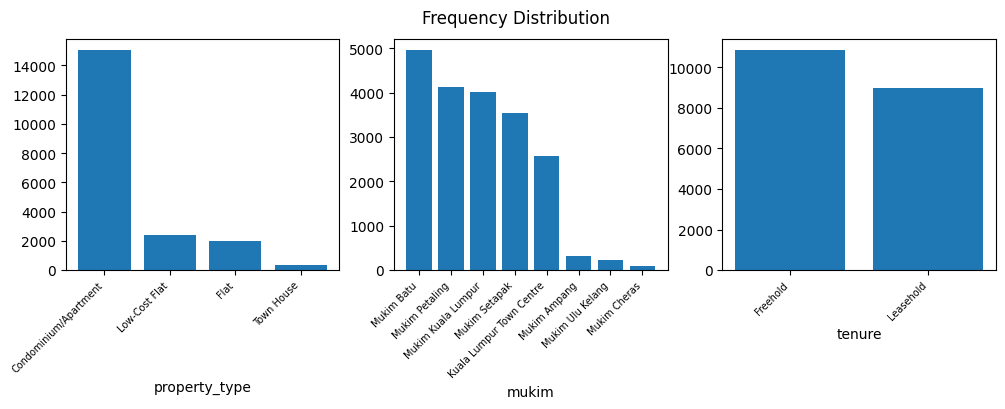

In [86]:
cat_list = ['property_type', 'mukim', 'tenure']
plot_category_count(df, cat_list)

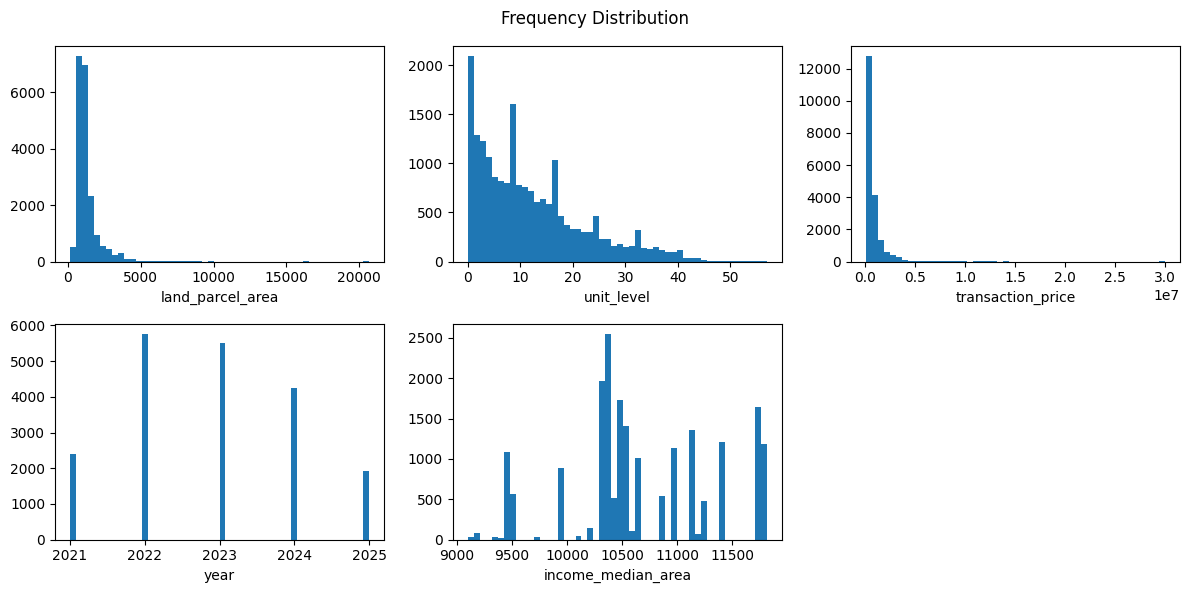

In [87]:
num_list = df.select_dtypes(np.number).columns
plot_num_count(df, num_list)

In [88]:
print(f"Median (50th percentile): Land area {df['land_parcel_area'].median():0.2f}, Price {df['transaction_price'].median()}")
print(f"80th percentile: Land area {df['land_parcel_area'].quantile(0.80):0.2f}, Price {df['transaction_price'].quantile(0.80)}")

Median (50th percentile): Land area 1074.99, Price 470000.0
80th percentile: Land area 1485.42, Price 1000000.0


In [89]:
df['land_parcel_area'].quantile(0.99)

np.float64(4014.9385792)

In [90]:
df['transaction_price'].quantile(0.99)

np.float64(4219089.999999956)

265


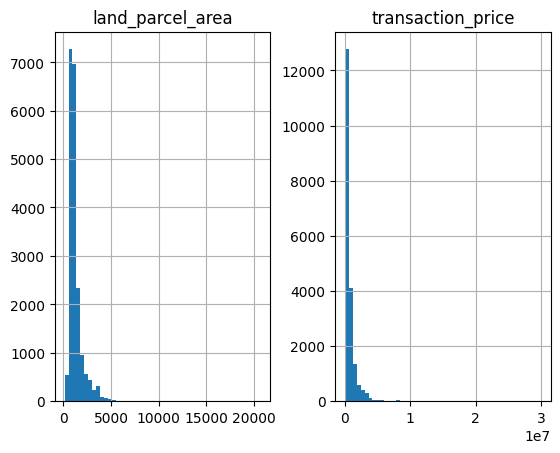

In [91]:
mask = (df['land_parcel_area'] > 4100) | (df['transaction_price'] > 4.3e6)
outliers = df[mask]
print(len(outliers))
df[['land_parcel_area', 'transaction_price']].hist(bins=50);

In [92]:
df.loc[df['land_parcel_area'] > 4100, 'land_parcel_area'] = 4200
df.loc[df['transaction_price'] > 4.3e6, 'transaction_price'] = 4.4e6
print(df.shape)

(19818, 9)


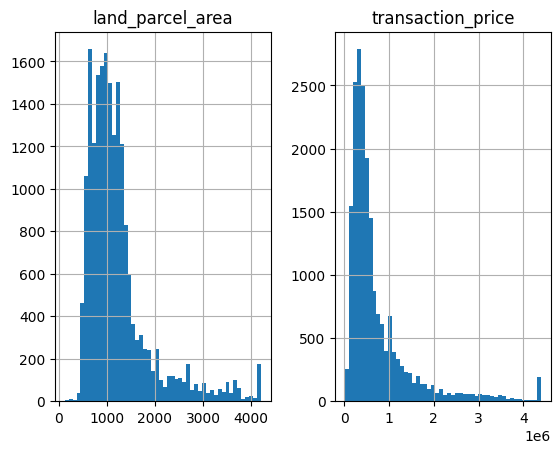

In [93]:
df[['land_parcel_area', 'transaction_price']].hist(bins=50);

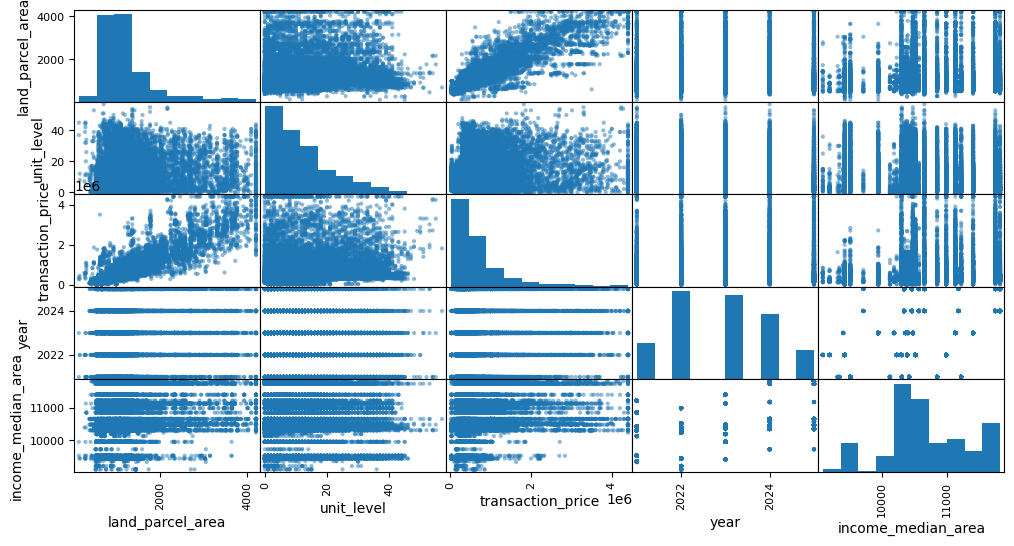

In [94]:
pd.plotting.scatter_matrix(df[num_list], figsize=(12,6))
plt.show()

In [95]:
df[num_list].corr()['transaction_price'].sort_values(ascending=False)

transaction_price     1.000000
land_parcel_area      0.881768
unit_level            0.246241
income_median_area    0.204109
year                  0.081714
Name: transaction_price, dtype: float64

In [96]:
from sklearn.model_selection import train_test_split

In [97]:
train_set, test_set = train_test_split(df, train_size=0.8, stratify=df['mukim'], random_state=1)
print(f"Shape: Train {train_set.shape}, Test {test_set.shape}")

Shape: Train (15854, 9), Test (3964, 9)


In [98]:
stratify = pd.DataFrame(df['mukim'].value_counts()/len(df)).rename(columns={'count':'original'})
stratify['stratified'] = train_set['mukim'].value_counts() / len(train_set)
non_stratified_train, _ = train_test_split(df, train_size=0.8, random_state=1)
stratify['non_stratified'] = non_stratified_train['mukim'].value_counts() / len(non_stratified_train)
stratify


,original,stratified,non_stratified
mukim,,,
Mukim Batu,0.250025,0.250032,0.249653
Mukim Petaling,0.207589,0.207582,0.206131
Mukim Kuala Lumpur,0.202341,0.202346,0.203986
Mukim Setapak,0.178928,0.178945,0.179955
Kuala Lumpur Town Centre,0.129428,0.129431,0.128800
Mukim Ampang,0.015642,0.015643,0.015643
Mukim Ulu Kelang,0.011606,0.011606,0.011101
Mukim Cheras,0.004440,0.004415,0.004731


In [99]:
train_set.head()

,property_type,mukim,scheme_name_area,tenure,land_parcel_area,unit_level,transaction_price,year,income_median_area
7725,Condominium/Apartment,Mukim Kuala Lumpur,MIDFIELDS SG.BESI KONDOMINIUM,Leasehold,1074.130619,7,420000,2021,11221.583852
15802,Flat,Mukim Batu,TMN SRI MURNI MEDIUM COST FLAT,Leasehold,764.237638,4,190000,2023,11131.878211
178,Condominium/Apartment,Kuala Lumpur Town Centre,CENDANA CONDO,Freehold,4200.000000,36,2300000,2022,10302.979398
4823,Condominium/Apartment,Mukim Batu,RESIDENSI SELINGSING,Freehold,861.112832,19,470000,2022,10518.458089
12690,Condominium/Apartment,Mukim Setapak,GENTING COURT,Leasehold,832.050274,12,250000,2021,9519.480524


In [100]:
train_set.groupby('mukim').nunique()

,property_type,scheme_name_area,tenure,land_parcel_area,unit_level,transaction_price,year,income_median_area
mukim,,,,,,,,
Kuala Lumpur Town Centre,4,244,2,341,57,607,5,4
Mukim Ampang,4,19,2,43,22,109,5,5
Mukim Batu,4,202,2,337,49,794,5,5
Mukim Cheras,4,6,2,20,18,46,5,5
Mukim Kuala Lumpur,4,202,2,281,45,719,5,4
Mukim Petaling,4,155,2,220,47,572,5,4
Mukim Setapak,4,145,2,205,47,533,5,4
Mukim Ulu Kelang,4,6,2,19,26,71,5,4


In [101]:
area_count = train_set.groupby('mukim')['scheme_name_area'].value_counts()
area_count

mukim                     scheme_name_area               
Kuala Lumpur Town Centre  RESIDENSI STAR                     66
                          RESIDENSI SETIA SKY SEPUTEH        57
                          THE ORION                          50
                          TAMAN MIHARJA                      42
                          TINGGIAN TITIWANGSA @ THE REACH    40
                                                             ..
Mukim Ulu Kelang          RESIDENSI SETIAWANGSA              23
                          PANGSA MURNI                        6
                          SRI KENANGAN                        6
                          BB WANGSA MAJU TOWNHOUSE            1
                          CENGAL KONDOMINIUM                  1
Name: count, Length: 979, dtype: int64

Group areas in each mukim by top 30 most frequent sales data with at least 10 unique sales for area_median_price mapping. Group the rest of the areas in each mukim under 'Others', with one 'Others' specifically for that mukim.

In [102]:
top_30 = area_count.groupby(level=0).head(30).index
outside = area_count[(area_count < 10) | (~area_count.index.isin(top_30))]
outside.reset_index()['mukim'].value_counts()

mukim
Kuala Lumpur Town Centre    214
Mukim Batu                  172
Mukim Kuala Lumpur          172
Mukim Petaling              125
Mukim Setapak               115
Mukim Ampang                 12
Mukim Ulu Kelang              4
Mukim Cheras                  3
Name: count, dtype: int64

In [103]:
outside_areas_list = outside.index.tolist()

is_outside_row = train_set.set_index(['mukim', 'scheme_name_area']).index.isin(outside_areas_list)
print(is_outside_row.sum())

7719


Leave-one-out target encoding of median transaction price within each unique area for each mukim. The same is applied to areas in 'outside_areas_list' but with median price of all the areas grouped as 'Others' instead of their respective unique areas.

In [104]:
def loo_median(x):
    return pd.Series(
        [x.drop(i).median() for i in x.index],
        index=x.index
    )

train_set['area_median_price'] = (
    train_set
    .groupby(['mukim', 'scheme_name_area'])['transaction_price']
    .apply(loo_median)
    .reset_index(level=[0, 1], drop=True)
)

def compute_mukim_others(group):
    prices = group['transaction_price']
    return pd.Series(
        [prices.drop(i).median() for i in prices.index],
        index=prices.index
    )

others_looe_series = train_set[is_outside_row].groupby('mukim', group_keys=False).apply(compute_mukim_others)


train_set.loc[is_outside_row, 'area_median_price'] = others_looe_series
train_set.loc[is_outside_row, 'scheme_name_area'] = 'Others'

C:\Users\DELL\AppData\Local\Temp\ipykernel_45200\2089253975.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  others_looe_series = train_set[is_outside_row].groupby('mukim', group_keys=False).apply(compute_mukim_others)


In [105]:
train_set.head(10)

,property_type,mukim,scheme_name_area,tenure,land_parcel_area,unit_level,transaction_price,year,income_median_area,area_median_price
7725,Condominium/Apartment,Mukim Kuala Lumpur,MIDFIELDS SG.BESI KONDOMINIUM,Leasehold,1074.130619,7,420000,2021,11221.583852,465000.0
15802,Flat,Mukim Batu,TMN SRI MURNI MEDIUM COST FLAT,Leasehold,764.237638,4,190000,2023,11131.878211,185000.0
178,Condominium/Apartment,Kuala Lumpur Town Centre,Others,Freehold,4200.000000,36,2300000,2022,10302.979398,565000.0
4823,Condominium/Apartment,Mukim Batu,RESIDENSI SELINGSING,Freehold,861.112832,19,470000,2022,10518.458089,475000.0
12690,Condominium/Apartment,Mukim Setapak,GENTING COURT,Leasehold,832.050274,12,250000,2021,9519.480524,214000.0
17524,Low-Cost Flat,Mukim Batu,Others,Leasehold,527.431610,4,110000,2023,11131.878211,580000.0
1331,Condominium/Apartment,Kuala Lumpur Town Centre,Others,Freehold,2755.561062,4,2880000,2025,10655.952127,565000.0
1259,Condominium/Apartment,Kuala Lumpur Town Centre,Others,Freehold,1270.141427,26,380000,2025,10655.952127,570000.0
5883,Condominium/Apartment,Mukim Batu,THE WESTSIDE ONE (DESA PARKCITY),Freehold,1819.100858,27,1520000,2025,11745.298333,1250000.0
16007,Flat,Mukim Kuala Lumpur,Others,Leasehold,968.751936,4,193000,2024,11817.214211,455000.0


Top 30 or qualified unique areas for each mukim as shown below. Every other area in each mukim is now grouped into a separate group 'Others' specific to that mukim.

In [106]:
train_set.groupby('mukim')['scheme_name_area'].nunique()

mukim
Kuala Lumpur Town Centre    31
Mukim Ampang                 8
Mukim Batu                  31
Mukim Cheras                 4
Mukim Kuala Lumpur          31
Mukim Petaling              31
Mukim Setapak               31
Mukim Ulu Kelang             3
Name: scheme_name_area, dtype: int64

In [107]:
train_set.groupby('mukim')['scheme_name_area'].value_counts()

mukim                     scheme_name_area           
Kuala Lumpur Town Centre  Others                         1154
                          RESIDENSI STAR                   66
                          RESIDENSI SETIA SKY SEPUTEH      57
                          THE ORION                        50
                          TAMAN MIHARJA                    42
                                                         ... 
Mukim Setapak             IRAMA WANGSA                     31
                          PLATINUM LAKE CONDO PV12         30
Mukim Ulu Kelang          PKNS ULU KELANG                 147
                          RESIDENSI SETIAWANGSA            23
                          Others                           14
Name: count, Length: 170, dtype: int64

In [108]:
train_set.groupby('mukim').nunique()

,property_type,scheme_name_area,tenure,land_parcel_area,unit_level,transaction_price,year,income_median_area,area_median_price
mukim,,,,,,,,,
Kuala Lumpur Town Centre,4,31,2,341,57,607,5,4,55
Mukim Ampang,4,8,2,43,22,109,5,5,17
Mukim Batu,4,31,2,337,49,794,5,5,52
Mukim Cheras,4,4,2,20,18,46,5,5,6
Mukim Kuala Lumpur,4,31,2,281,45,719,5,4,57
Mukim Petaling,4,31,2,220,47,572,5,4,49
Mukim Setapak,4,31,2,205,47,533,5,4,52
Mukim Ulu Kelang,4,3,2,19,26,71,5,4,5


In [109]:
train_set.corr(numeric_only=True)['transaction_price'].sort_values(ascending=False)

transaction_price     1.000000
land_parcel_area      0.881972
area_median_price     0.667551
unit_level            0.240863
income_median_area    0.202574
year                  0.092735
Name: transaction_price, dtype: float64

In [110]:
#train_set.to_csv("../data/train_set.csv", index=False)
#test_set.to_csv("../data/test_set.csv", index=False)

In [111]:
mapping = train_set.groupby('mukim')['scheme_name_area'].unique()

mapping_dict = {mukim: sorted(schemes.tolist()) for mukim, schemes in mapping.items()}

#with open('../data/mukim_scheme_mapping.json', 'w') as f:
    #json.dump(mapping_dict, f, indent=4)

print("mukim to area mapping saved to data/mukim_scheme_mapping.json")

mukim to area mapping saved to data/mukim_scheme_mapping.json


In [112]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

In [113]:
area_mapping = train_set.groupby(['mukim', 'scheme_name_area'])['area_median_price'].median().to_dict()

others_value_by_mukim = (
    train_set[train_set['scheme_name_area'] == 'Others']
    .groupby('mukim')['area_median_price']
    .median()
)

others_value = train_set['area_median_price'].median()

def map_test_row(row):
    key = (row['mukim'], row['scheme_name_area'])
    
    if key in area_mapping:
        return area_mapping[key]
    
    return others_value_by_mukim.get(row['mukim'], others_value)

test_set['area_median_price'] = test_set.apply(map_test_row, axis=1)
test_set.head()

,property_type,mukim,scheme_name_area,tenure,land_parcel_area,unit_level,transaction_price,year,income_median_area,area_median_price
967,Condominium/Apartment,Kuala Lumpur Town Centre,PARK SEVEN,Freehold,4200.000000,8,4400000,2025,10655.952127,567500.0
15373,Flat,Mukim Ampang,DESA PANDAN,Leasehold,721.181997,4,300000,2022,10231.924082,300000.0
11542,Condominium/Apartment,Mukim Petaling,RESIDENSI HAMSTEAD,Leasehold,947.008837,16,411000,2024,10346.591315,375000.0
884,Condominium/Apartment,Kuala Lumpur Town Centre,PANGSAPURI BANDAR BARU SENTUL,Leasehold,559.723341,5,150000,2022,10302.979398,209000.0
8199,Condominium/Apartment,Mukim Kuala Lumpur,PRISMA PERDANA APT,Freehold,818.057190,6,300000,2023,11404.069649,321000.0


In [114]:
X_train = train_set.drop(columns=['transaction_price', 'year', 'scheme_name_area'])
y_train = train_set['transaction_price']
X_test = test_set.drop(columns=['transaction_price', 'year', 'scheme_name_area'])
y_test = test_set['transaction_price']
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [116]:
model = RandomForestRegressor(random_state=1)
model.fit(X_train, y_train)
y_hat_train = model.predict(X_train)
print(f"RMSE: {root_mean_squared_error(y_train, y_hat_train)}")
print(f"MAPE: {mean_absolute_percentage_error(y_train, y_hat_train)}")

RMSE: 76561.40222464
MAPE: 0.06222738938456701


In [117]:
y_hat_test = model.predict(X_test)
print(f"RMSE: {root_mean_squared_error(y_test, y_hat_test)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_hat_test)}")

RMSE: 208175.37423007327
MAPE: 0.19842227105098736


Baseline performance:  
- RMSE: RM 208,000
- MAPE: 19.8%